In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load stock dataset
df = pd.read_csv('../../Data sets/2) Stock Prices Data Set.csv')

# Clean column names (strip whitespace and convert to lowercase for searching)
df.columns = df.columns.str.strip()
print("=== EXACT COLUMNS FOUND IN CSV ===")
print(df.columns.tolist())

# Automatically detect the date and close price columns
date_col = next((col for col in df.columns if col.lower() in ['date', 'timestamp', 'time', 'day']), df.columns[0])
close_col = next((col for col in df.columns if col.lower() in ['close', 'adj close', 'price', 'last']), df.columns[1])

print(f"\nUsing '{date_col}' as Date column and '{close_col}' as Close Price column.")

# Rename columns to standard names
df = df.rename(columns={date_col: 'Date', close_col: 'Close'})

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Calculate Daily Return percentage
df['Daily_Return'] = df['Close'].pct_change() * 100

print("\n=== CLEANED DATA PREVIEW ===")
print(df.head())

=== EXACT COLUMNS FOUND IN CSV ===
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Using 'date' as Date column and 'close' as Close Price column.

=== CLEANED DATA PREVIEW ===
    symbol       Date   open   high     low  Close   volume  Daily_Return
0      AAL 2014-01-02  25.07  25.82  25.060  25.36  8998943           NaN
330   NVDA 2014-01-02  15.92  15.98  15.720  15.86  6502296    -37.460568
329    NUE 2014-01-02  53.29  53.38  52.510  52.73  1611326    232.471627
328   NTRS 2014-01-02  61.76  61.95  60.665  60.89  1011050     15.475062
327   NTAP 2014-01-02  41.01  41.01  40.415  40.42  2427140    -33.618000


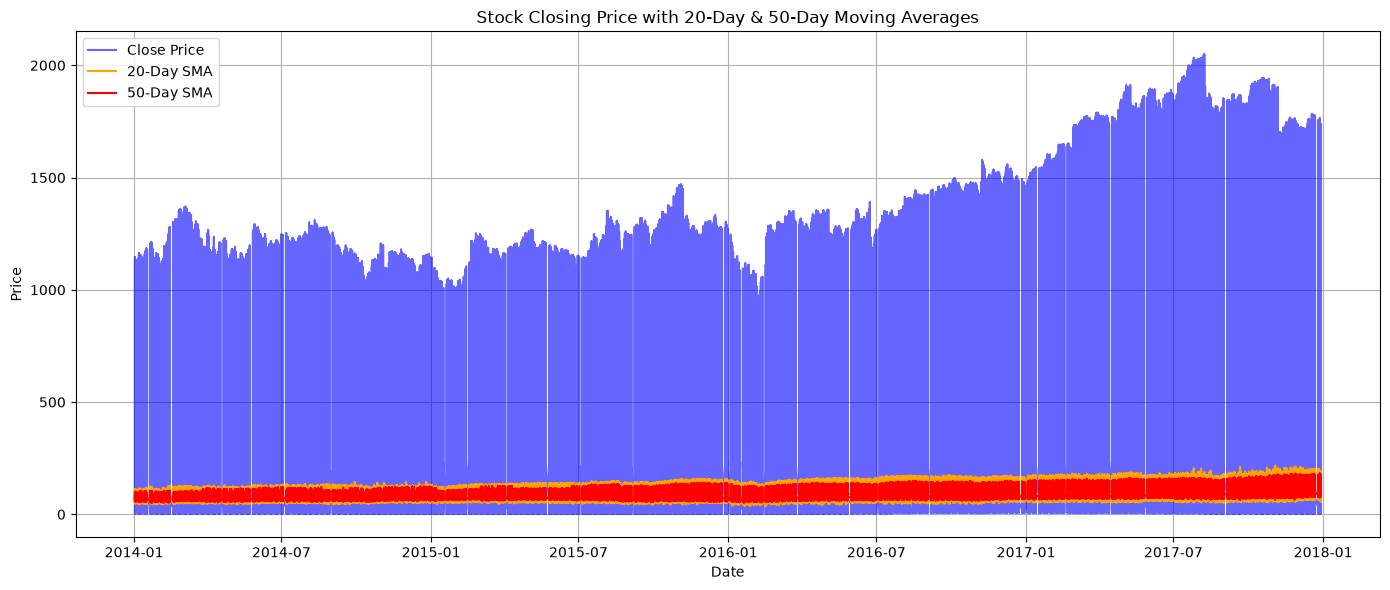

In [3]:
# Calculate 20-day and 50-day Simple Moving Averages (SMA)
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Plot Price Trends with Moving Averages
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue', alpha=0.6)
plt.plot(df['Date'], df['SMA_20'], label='20-Day SMA', color='orange', linewidth=1.5)
plt.plot(df['Date'], df['SMA_50'], label='50-Day SMA', color='red', linewidth=1.5)

plt.title('Stock Closing Price with 20-Day & 50-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

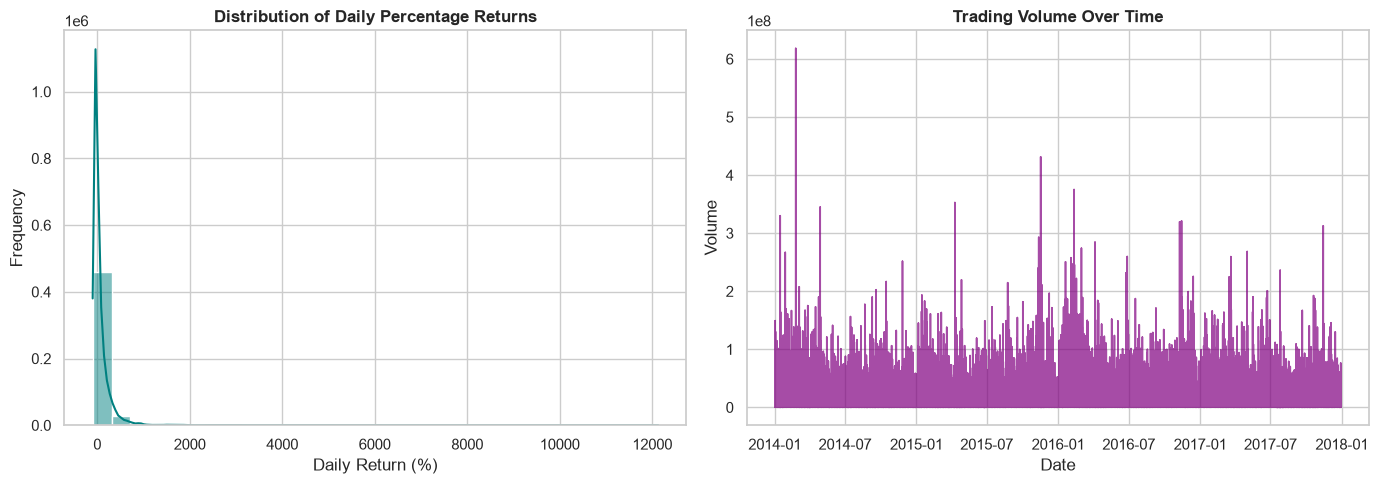

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of Daily Percentage Returns
if 'Daily_Return' not in df.columns:
    df['Daily_Return'] = df['Close'].pct_change() * 100

sns.histplot(df['Daily_Return'].dropna(), kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Distribution of Daily Percentage Returns', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')

# 2. Trading Volume Over Time (dynamically find Volume column)
vol_col = next((col for col in df.columns if 'vol' in col.lower()), None)

if vol_col and vol_col in df.columns:
    axes[1].plot(df['Date'], df[vol_col], color='purple', alpha=0.7, linewidth=1.2)
    axes[1].set_title('Trading Volume Over Time', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Volume')
else:
    axes[1].plot(df['Date'], df['Close'], color='blue', alpha=0.7, linewidth=1.2)
    axes[1].set_title('Closing Price Trend', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Close Price')

plt.tight_layout()
plt.show()

In [ ]:
S